# Backpropagation — How Neural Networks Learn

## Goal
Understand how gradients flow backward through a network.
Backpropagation is the algorithm that makes deep learning possible.

## Key Questions
- What is a gradient and why does it matter?
- How does the chain rule connect layers?
- What happens when gradients vanish or explode?

## What We Build
Step-by-step backpropagation visualization — showing exactly what each gradient means.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. What is a Gradient?
A gradient tells us: "if I change this weight slightly, how much does the loss change?"
- Positive gradient → weight is too high → decrease it
- Negative gradient → weight is too low → increase it
- Zero gradient → weight is at the right value

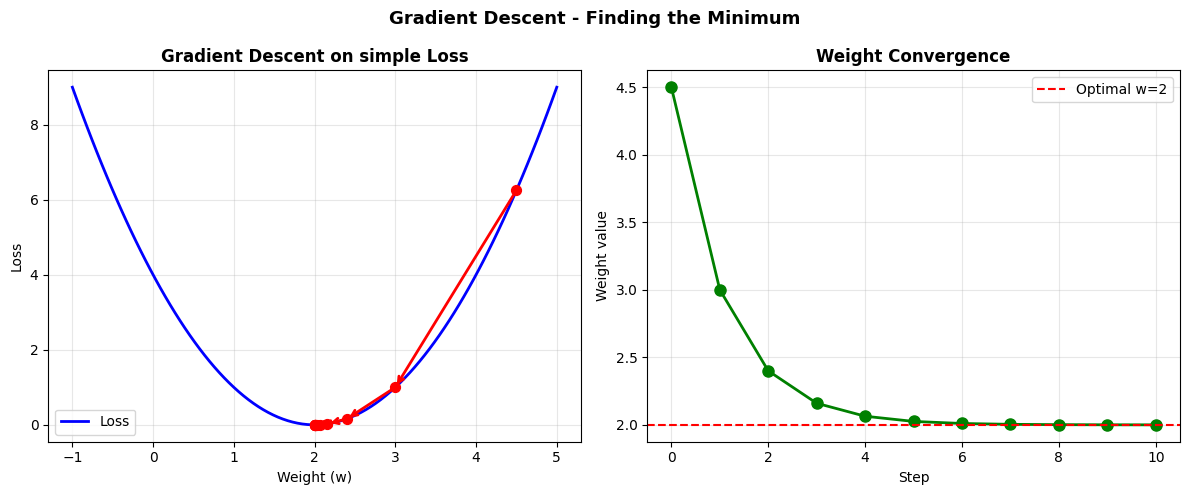

Started at w = 4.5
Ended at w = 2.0003
Optimal w = 2.0


In [4]:
# Simple example - visualize what gradient means
def loss_function(w: float) -> float:
    """Simple parabolic loss - minimum at w=2."""
    return (w - 2) ** 2

def gradient(w: float) -> float:
    """Derivative of loss - tells us which direction to move."""
    return 2 * (w - 2)

w_values = np.linspace(-1, 5, 100)
loss_values = [loss_function(w) for w in w_values]

# Gradient descent simulation
w = 4.5 # start far from minimum
learning_rate = 0.3
history = [w]

for _ in range(10):
    grad = gradient(w)
    w = w - learning_rate * grad
    history.append(w)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1 - Loss landscape with gradient descent steps
axes[0].plot(w_values, loss_values, "b-", linewidth=2, label="Loss")
for i, w_h in enumerate(history[:-1]):
    axes[0].annotate("",
                    xy=(history[i+1], loss_function(history[i+1])),
                    xytext=(w_h, loss_function(w_h)),
                    arrowprops=dict(arrowstyle="->", color="red", lw=2))
axes[0].scatter([w_h for w_h in history],
               [loss_function(w_h) for w_h in history],
               c="red", s=50, zorder=5)
axes[0].set_title("Gradient Descent on simple Loss", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Weight (w)")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2 - Weight convergence
axes[1].plot(history, "g-o", linewidth=2, markersize=8)
axes[1].axhline(2.0, color="red", linestyle="--", label="Optimal w=2")
axes[1].set_title("Weight Convergence", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Weight value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Gradient Descent - Finding the Minimum", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("gradient_descent.png", dpi=300)
plt.show()

print(f"Started at w = 4.5")
print(f"Ended at w = {history[-1]:.4f}")
print(f"Optimal w = 2.0")

## 2. Chain Rule — How Gradients Flow Through Layers
Backpropagation uses the chain rule to compute gradients layer by layer.
If L depends on a, and a depends on z, and z depends on w:
dL/dw = dL/da * da/dz * dz/dw

In [7]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# Simple 2-layer network - trace every gradient manually
np.random.seed(42)

# Single training example
x = np.array([[1.0, 0.0]]) # input
y = np.array([[1.0]])      # target

# Weights
W1 = np.array([[0.5, -0.3], [0.2, 0.8]])
b1 = np.array([[0.0, 0.0]])
W2 = np.array([[0.6], [-0.4]])
b2 = np.array([[0.0]])

# Forward pass
z1 = np.dot(x, W1) + b1
a1 = sigmoid(z1)
z2 = np.dot(a1, W2) + b2
a2 = sigmoid(z2)
loss = 0.5 * (a2 - y) ** 2

print("=== FORWARD PASS ===")
print(f"Input x:     {x}")
print(f"z1:          {z1.round(4)}")
print(f"a1:          {a1.round(4)}")
print(f"z2:          {z2.round(4)}")
print(f"a2 (output): {a2.round(4)}")
print(f"Target y:    {y}")
print(f"Loss:        {loss[0][0]:.6f}")

# backward pass - chain rule
print("\n=== BACKWARD PASS===")
dL_da2 = a2 - y
print(f"dL/da2: {dL_da2.round(4)}")

dL_dz2 = dL_da2 * sigmoid_derivative(z2)
print(f"dL/dz2: {dL_dz2.round(4)}")

dL_dW2 = np.dot(a1.T, dL_dz2)
print(f"dL/da1: {dL_dW2.round(4)}")

dL_da1 = np.dot(dL_dz2, W2.T)
print(f"dL/da1: {dL_da1.round(4)}")

dL_dz1 = dL_da1 * sigmoid_derivative(z1)
print(f"dL/dz1: {dL_dz1.round(4)}")

dL_dW1 = np.dot(x.T, dL_dz1)
print(f"dL/dW1: {dL_dW1.round(4)}")

=== FORWARD PASS ===
Input x:     [[1. 0.]]
z1:          [[ 0.5 -0.3]]
a1:          [[0.6225 0.4256]]
z2:          [[0.2033]]
a2 (output): [[0.5506]]
Target y:    [[1.]]
Loss:        0.100963

=== BACKWARD PASS===
dL/da2: [[-0.4494]]
dL/dz2: [[-0.1112]]
dL/da1: [[-0.0692]
 [-0.0473]]
dL/da1: [[-0.0667  0.0445]]
dL/dz1: [[-0.0157  0.0109]]
dL/dW1: [[-0.0157  0.0109]
 [ 0.      0.    ]]


## 3. Vanishing Gradient Problem

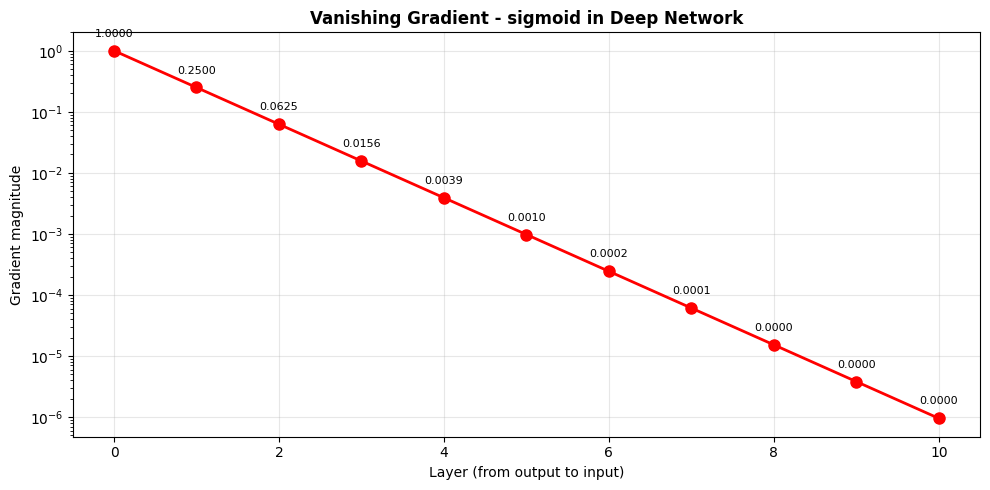

Gradient at each layer:
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]
Layer [i]: [g:.8f]


In [10]:
# Show how sigmoid derivatives get smaller in deep networks
layers = 10
initial_gradient = 1.0
gradients = [initial_gradient]

x_val = 0.0  # worst case — sigmoid derivative is max here (0.25)

for i in range(layers):
    grad = gradients[-1] * sigmoid_derivative(x_val)
    gradients.append(grad)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(gradients, "r-o" , linewidth=2, markersize=8)
ax.set_title("Vanishing Gradient - sigmoid in Deep Network",
            fontsize=12, fontweight="bold")
ax.set_xlabel("Layer (from output to input)")
ax.set_ylabel("Gradient magnitude")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

for i, g in enumerate(gradients):
    ax.annotate(f"{g:.4f}", (i, g), textcoords="offset points",
               xytext=(0, 10), ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("vanishing_gradient.png", dpi=300)
plt.show()

print("Gradient at each layer:")
for i, g in enumerate(gradients):
    print(f"Layer [i]: [g:.8f]")

## 4. Key Observations

## What Backpropagation Does
1. Forward pass: compute predictions layer by layer
2. Compute loss: how wrong are we?
3. Backward pass: use chain rule to compute gradient for every weight
4. Update weights: move each weight in the direction that reduces loss

## Vanishing Gradient
With sigmoid activation in deep networks:
- Each layer multiplies gradient by sigmoid_derivative (max 0.25)
- After 10 layers: 1.0 → 0.000001
- Early layers learn almost nothing — they receive near-zero gradients

## Why This Matters
This is why sigmoid was replaced by ReLU in deep networks.
ReLU derivative is either 0 or 1 — gradients don't shrink.
This made training deep networks practical.

## Key Insight
Backpropagation is just the chain rule applied systematically.
Every weight gets a gradient that tells it exactly how to change.
The learning rate controls how big each step is.

## Next
How do convolutional networks detect patterns in images?
-> 04_cnn_basics.ipynb